# 03 — Returns and Discount Factor
**Week 3 | RL Fundamentals**

The **return** G_t is the cumulative reward from time t onwards:

$$G_t = R_{t+1} + \gamma R_{t+2} + \gamma^2 R_{t+3} + \cdots = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

The discount factor γ ∈ [0,1) controls how much the agent cares about future rewards.

In [15]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Computing Returns

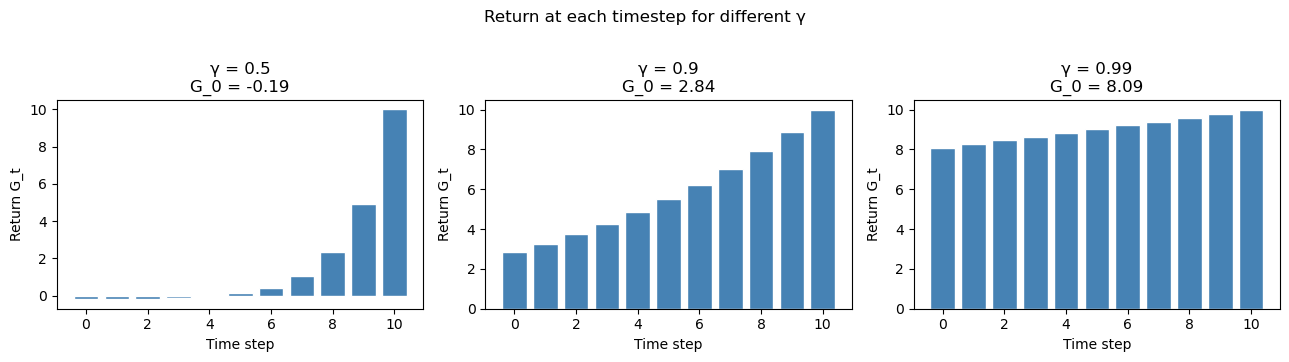

In [16]:
def compute_returns(rewards, gamma):
    """Compute discounted returns for a list of rewards (backwards pass)."""
    G = np.zeros(len(rewards))
    running = 0.0
    for t in reversed(range(len(rewards))):
        running = rewards[t] + gamma * running
        G[t] = running
    return G

# Example trajectory: -0.1 per step, +10 at end
rewards = [-0.1] * 10 + [10.0]
t = np.arange(len(rewards))

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, gamma in zip(axes, [0.5, 0.9, 0.99]):
    G = compute_returns(rewards, gamma)
    ax.bar(t, G, color='steelblue', edgecolor='white')
    ax.set_title(f'γ = {gamma}\nG_0 = {G[0]:.2f}')
    ax.set_xlabel('Time step'); ax.set_ylabel('Return G_t')
plt.suptitle('Return at each timestep for different γ', y=1.02)
plt.tight_layout(); plt.show()

## 2. Effect of γ on Discount Weights

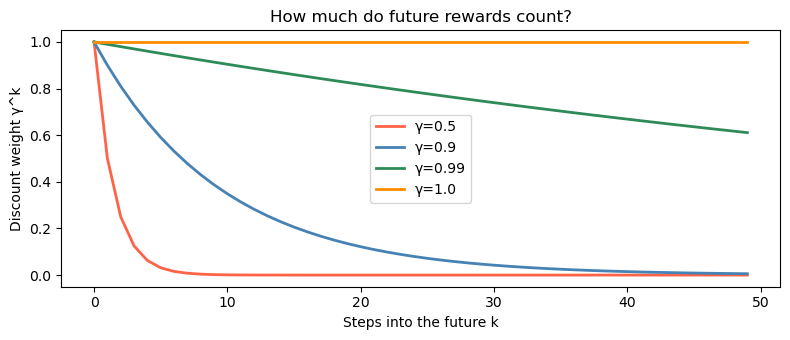


A reward 20 steps away is worth:
  γ=0.5: 0.0000 of its face value
  γ=0.9: 0.1216 of its face value
  γ=0.99: 0.8179 of its face value
  γ=1.0: 1.0000 of its face value


In [17]:
steps = np.arange(0, 50)
fig, ax = plt.subplots(figsize=(8, 3.5))
for gamma, color in [(0.5,'tomato'),(0.9,'steelblue'),(0.99,'seagreen'),(1.0,'darkorange')]:
    weights = gamma ** steps
    ax.plot(steps, weights, label=f'γ={gamma}', linewidth=2, color=color)
ax.set_xlabel('Steps into the future k')
ax.set_ylabel('Discount weight γ^k')
ax.set_title('How much do future rewards count?')
ax.legend(); plt.tight_layout(); plt.show()
print("\nA reward 20 steps away is worth:")
for g in [0.5, 0.9, 0.99, 1.0]:
    print(f"  γ={g}: {g**20:.4f} of its face value")

## 3. Episodic vs Continuing Tasks

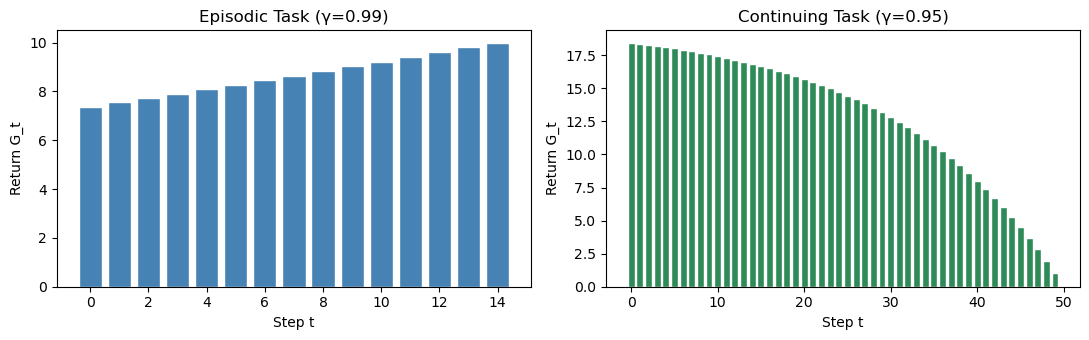

Continuing task: geometric series limit = R/(1-γ) = 20.0
Empirical G_0 = 18.46


In [18]:
# Episodic: trajectory has a natural end (e.g. reaching the goal)
def episodic_returns(n_steps=15, goal_reward=10.0, step_cost=-0.1, gamma=0.99):
    rewards = [step_cost] * (n_steps-1) + [goal_reward]
    return compute_returns(rewards, gamma)

# Continuing: no terminal state; must use discounting to keep G finite
def continuing_returns(n_steps=50, reward_per_step=1.0, gamma=0.95):
    rewards = [reward_per_step] * n_steps
    return compute_returns(rewards, gamma)

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
g_ep = episodic_returns()
axes[0].bar(range(len(g_ep)), g_ep, color='steelblue', edgecolor='white')
axes[0].set_title('Episodic Task (γ=0.99)')
axes[0].set_xlabel('Step t'); axes[0].set_ylabel('Return G_t')

g_cont = continuing_returns()
axes[1].bar(range(len(g_cont)), g_cont, color='seagreen', edgecolor='white')
axes[1].set_title('Continuing Task (γ=0.95)')
axes[1].set_xlabel('Step t'); axes[1].set_ylabel('Return G_t')
plt.tight_layout(); plt.show()

print(f"Continuing task: geometric series limit = R/(1-γ) = {1.0/(1-0.95):.1f}")
print(f"Empirical G_0 = {g_cont[0]:.2f}")

## 4. The Bellman Equation for Returns
G_t = R_{t+1} + γ * G_{t+1}  — the key recursive structure used by all RL algorithms.

In [19]:
rewards = np.random.randn(20)  # random rewards
gamma   = 0.9
G = compute_returns(rewards, gamma)

# Verify Bellman equation: G[t] == rewards[t+1] + gamma * G[t+1]
for t in range(len(G)-1):
    lhs = G[t]
    rhs = rewards[t] + gamma * G[t+1]
    assert np.isclose(lhs, rhs), f"Mismatch at t={t}: {lhs:.4f} vs {rhs:.4f}"
print("✅ Bellman equation verified for all timesteps")

✅ Bellman equation verified for all timesteps


## ✅ Exercises
1. Set γ=0 and γ=1 and describe what kind of agent each creates. Is γ=1 ever safe for a continuing task?
2. Compute the optimal γ for a task where rewards are [1, 1, 1, ..., 100] after 50 steps. At what γ does the far reward contribute at least 50% of G_0?
3. **Challenge**: implement `compute_returns_forward` — compute G_t without reversing the array (hint: use the geometric series formula).

Ans 1) My Observation - 	γ=0:	G_t	=	R_{t+1}	only.	A	completely	myopic	agent
—	it	sees	the	−0.1	step	cost	and	nothing	else,	so	the	+10	goal	is
invisible	until	the	final	step.	It	would	never	learn	to	walk	toward	a
distant	reward.	-	γ=1:	every	future	reward	counts	fully	—	maximally
far-sighted.	Safe	only	for	episodic	tasks	(finite	sum).	For	a
continuing	task	G_t	=	Σ	r	diverges	to	∞,	value	functions	become
undefined,	and	nothing	can	be	compared.	That’s	why	the	MDP
definition	in	notebook	01	states	γ	∈	[0,1)	—	strictly	below	1	

In [20]:
rewards	=	[-0.1]	*	10	+	[10.0]
for	gamma	in	[0.0,	1.0]:
				G	=	compute_returns(rewards,	gamma)
				print(f"γ={gamma}:		G_0	=	{G[0]:.2f}			G	=	{np.round(G,	2)}")

γ=0.0:		G_0	=	-0.10			G	=	[-0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 -0.1 10. ]
γ=1.0:		G_0	=	9.00			G	=	[ 9.   9.1  9.2  9.3  9.4  9.5  9.6  9.7  9.8  9.9 10. ]


Ans 2)

Far	reward	contributes	≥50%	of	G_0	from	γ	≈	0.9756


C:\Users\arinu\AppData\Local\Temp\ipykernel_36524\582658645.py:19: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  plt.legend();	plt.tight_layout();	plt.show()


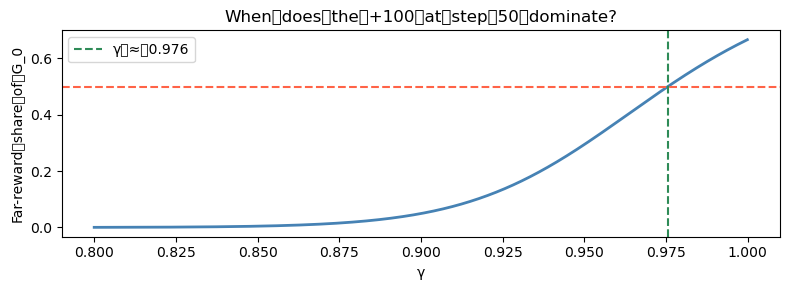

In [21]:
rewards	=	[1.0]	*	50	+	[100.0]					#	50	steps	of	+1,	then	+100
gammas	=	np.linspace(0.80,	0.9999,	2000)
threshold_gamma	=	None
for	g	in	gammas:
				G0	=	compute_returns(rewards,	g)[0]
				far_contrib	=	(g	**	50)	*	100.0
				if	far_contrib	/	G0	>=	0.5:
								threshold_gamma	=	g
								break
print(f"Far	reward	contributes	≥50%	of	G_0	from	γ	≈	{threshold_gamma:.4f}")
#	visual
fracs	=	[(g**50	*	100.0)	/	compute_returns(rewards,	g)[0]	for	g	in	gammas]
plt.figure(figsize=(8,	3))
plt.plot(gammas,	fracs,	color='steelblue',	linewidth=2)
plt.axhline(0.5,	color='tomato',	linestyle='--')
plt.axvline(threshold_gamma,	color='seagreen',	linestyle='--', label=f'γ	≈	{threshold_gamma:.3f}')
plt.xlabel('γ');	plt.ylabel('Far-reward	share	of	G_0')
plt.title('When	does	the	+100	at	step	50	dominate?')
plt.legend();	plt.tight_layout();	plt.show()

Threshold	lands	around	γ	≈	0.975.	Below	that,
γ^50	crushes	the	+100	(at	γ=0.9,	γ^50	≈	0.005	→	the	100	is	worth
~0.5).	Rule	of	thumb	this	teaches:	effective	planning	horizon	≈
1/(1−γ),	so	to	“see”	50	steps	ahead	you	need	γ	≳	0.98	comfortably,	and
≥0.93	just	to	break	even	against	near-term	rewards.

Ans 3) Assertion	passes

In [22]:
def	compute_returns_forward(rewards,	gamma):
				"""
				G_t	=	Σ_{k≥t}	γ^(k-t)	r_k		=		(Σ_{k≥t}	γ^k	r_k)	/	γ^t
				One	forward	cumsum,	no	reversed()	loop.
				"""
				r	=	np.asarray(rewards,	dtype=float)
				powers	=	gamma	**	np.arange(len(r))										#	γ^0,	γ^1,	...
				weighted	=	r	*	powers																								#	γ^k	r_k
				csum	=	np.cumsum(weighted)
				prefix	=	np.concatenate([[0.0],	csum[:-1]])		#	Σ_{k<t}
				return	(csum[-1]	-	prefix)	/	powers										#	suffix	sum	÷	γ^t
#	verify	against	the	backward	version
rewards	=	np.random.randn(20)
gamma	=	0.9
G_back	=	compute_returns(rewards,	gamma)
G_fwd		=	compute_returns_forward(rewards,	gamma)
assert	np.allclose(G_back,	G_fwd),	"Mismatch!"
print("Forward	computation	matches	backward	pass")
print(np.round(G_fwd[:5],	4))

Forward	computation	matches	backward	pass
[-1.1705 -2.3841 -2.2105 -2.5415 -2.1183]
